# Pistachio Variety Image Classification

### CNN and Transfer Learning with MobileNetV2

### Introduction

This project focuses on image classification of two pistachio varieties: **Kirmizi Pistachio** and **Siirt Pistachio**.

The dataset contains **2,148 pistachio images**. The objective is to build a binary image classification model using **Convolutional Neural Networks (CNN)** and **Transfer Learning**.

A pre-trained **MobileNetV2** model is used as the feature extractor, allowing previously learned visual features from ImageNet to be transferred to the pistachio classification task.

<img src='https://pfst.cf2.poecdn.net/base/image/a04bb4cda3a2aeccab00a81079089c48ebe0284033f77d161b2b3ccb6fa8c4dd?w=1024&h=768&pmaid=260299863' width='800'>
<a href='https://www.muratkoklu.com/datasets/' target=_blank>
Click here for the dataset </a>

**Import libraries**

In [1]:
import os
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import os

data_dir = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset'

print("Dataset exists:", os.path.exists(data_dir))
print("Folders:", os.listdir(data_dir))

Dataset exists: True
Folders: ['Pistachio_Image_Dataset_Request.txt', 'Siirt_Pistachio', 'Kirmizi_Pistachio']


In [8]:
# Paths to the two pistachio classes
file_path_kirmizi = os.path.join(data_dir, 'Kirmizi_Pistachio')
file_path_siirt = os.path.join(data_dir, 'Siirt_Pistachio')

In [9]:
# List the image files in both folders
kirmizi_images = os.listdir(file_path_kirmizi)
siirt_images = os.listdir(file_path_siirt)

In [13]:
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

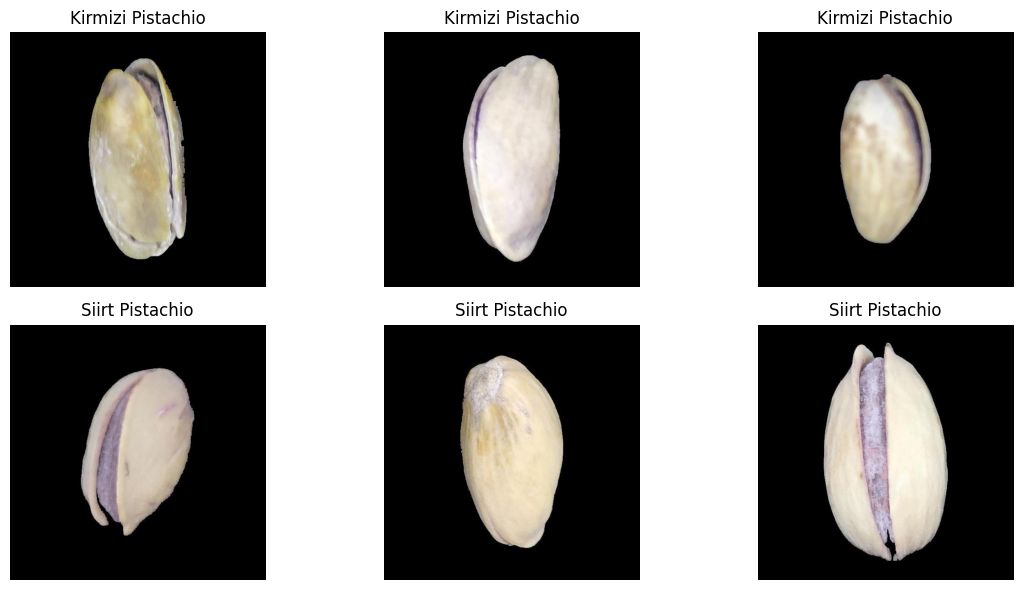

In [14]:
# Paths to the image folders
file_path_kirmizi = os.path.join(data_dir, 'Kirmizi_Pistachio')
file_path_siirt = os.path.join(data_dir, 'Siirt_Pistachio')

# Create lists of image files
kirmizi_images = os.listdir(file_path_kirmizi)
siirt_images = os.listdir(file_path_siirt)

# Select random images
random_kirmizi = random.sample(kirmizi_images, 3)
random_siirt = random.sample(siirt_images, 3)

# Create a grid with 2 rows and 3 columns
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

# Show images from Kirmizi
for i, img_name in enumerate(random_kirmizi):
    img = mpimg.imread(os.path.join(file_path_kirmizi, img_name))
    axs[0, i].imshow(img)
    axs[0, i].axis('off')
    axs[0, i].set_title('Kirmizi Pistachio')

# Show images from Siirt
for i, img_name in enumerate(random_siirt):
    img = mpimg.imread(os.path.join(file_path_siirt, img_name))
    axs[1, i].imshow(img)
    axs[1, i].axis('off')
    axs[1, i].set_title('Siirt Pistachio')

# Display the grid
plt.tight_layout()
plt.show()

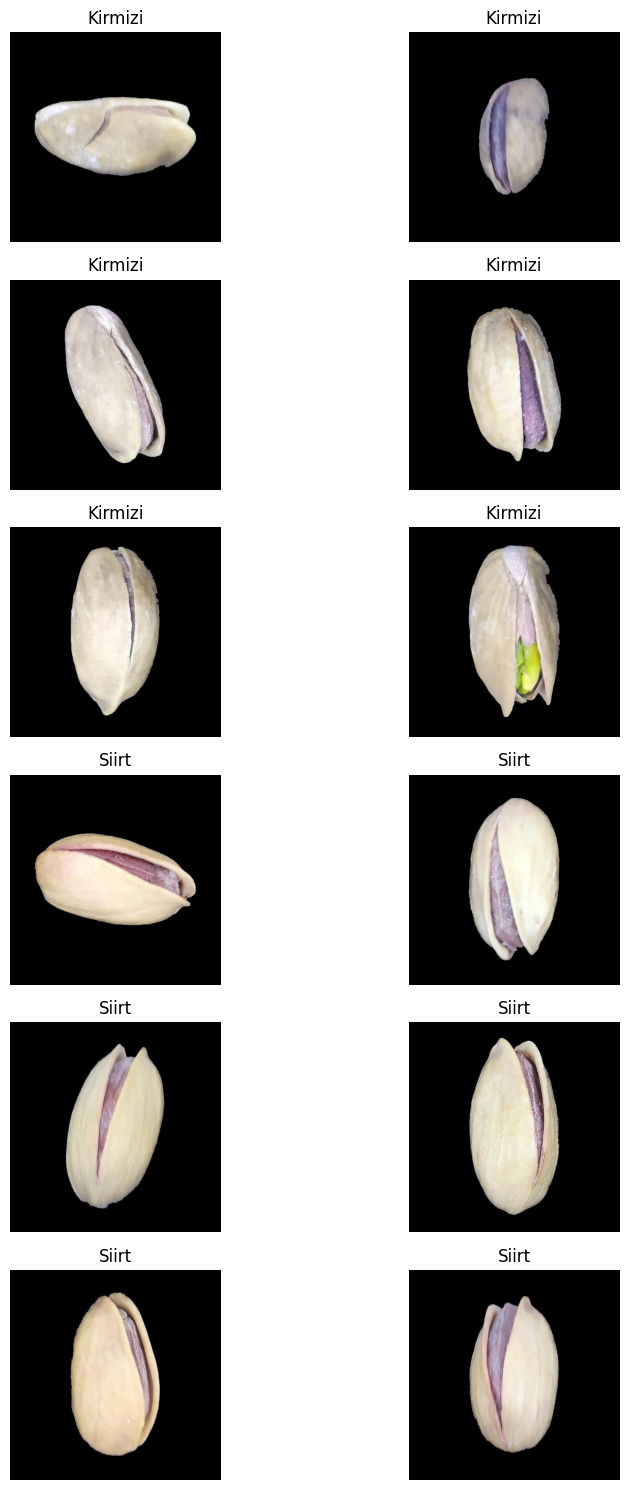

In [15]:
# Select the first 6 images from each class
kirmizi_images = [
    f for f in os.listdir(file_path_kirmizi)
    if f.endswith(('.jpg', '.png'))
][:6]

siirt_images = [
    f for f in os.listdir(file_path_siirt)
    if f.endswith(('.jpg', '.png'))
][:6]

# Combine image names and labels
sample_images = kirmizi_images + siirt_images
labels = ['Kirmizi'] * len(kirmizi_images) + ['Siirt'] * len(siirt_images)

# Display sample images
plt.figure(figsize=(10, 15))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(
        file_path_kirmizi if i < 6 else file_path_siirt,
        img_name
    )

    img = mpimg.imread(img_path)

    plt.subplot(6, 2, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(labels[i])

plt.tight_layout()
plt.show()

**Data Preparation**

In [16]:
import tensorflow as tf

data_dir = '/content/drive/MyDrive/Pistachio_Image_Dataset/Pistachio_Image_Dataset'

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(128, 128),
    batch_size=16,
    label_mode='categorical',
    validation_split=0.2,
    subset='training',
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(128, 128),
    batch_size=16,
    label_mode='categorical',
    validation_split=0.2,
    subset='validation',
    seed=123
)

print("Class names:", train_ds.class_names)
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())

Found 2148 files belonging to 2 classes.
Using 1719 files for training.
Found 2148 files belonging to 2 classes.
Using 429 files for validation.
Class names: ['Kirmizi_Pistachio', 'Siirt_Pistachio']
Training batches: 108
Validation batches: 27


**Transfer Learning Model with MobileNetV2**

>Instead of training a CNN entirely from scratch, this project uses **MobileNetV2**, pre-trained on ImageNet, as a feature extractor.

>The convolutional base is initially frozen so that its previously learned visual features can be reused for the pistachio classification task. A new classification head is then trained for the two pistachio varieties.

In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Rescaling, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import MobileNetV2

In [18]:
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
model = Sequential([
    Rescaling(1./127.5, offset=-1, input_shape=(128, 128, 3)),
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 337s 3s/step - accuracy: 0.7760 - loss: 0.4913 - val_accuracy: 0.9044 - val_loss: 0.2356
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.9063 - loss: 0.2301 - val_accuracy: 0.9441 - val_loss: 0.1672
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.9290 - loss: 0.1709 - val_accuracy: 0.9604 - val_loss: 0.1307
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 18s 169ms/step - accuracy: 0.9412 - loss: 0.1471 - val_accuracy: 0.9604 - val_loss: 0.1235
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 153ms/step - accuracy: 0.9523 - loss: 0.1334 - val_accuracy: 0.9674 - val_loss: 0.1081
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.9575 - loss: 0.1262 - val_accuracy: 0.9627 - val_loss: 0.1048
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 17s 155ms/step - accuracy: 0.9628 - loss: 0.1163 - val_accuracy: 0.9627 - val_loss: 0.1071
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 19s 170ms/step - accuracy: 0.9628 - loss: 0.1

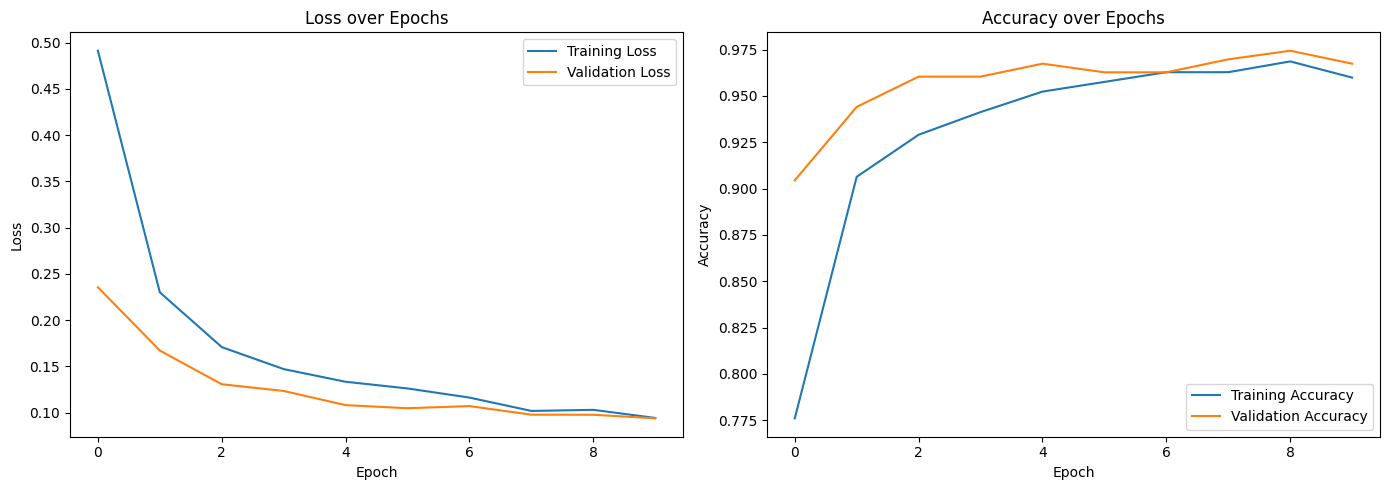

In [21]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Training Accuracy: {final_train_accuracy:.4f}")
print(f"Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Training Loss: {final_train_loss:.4f}")
print(f"Validation Loss: {final_val_loss:.4f}")

Training Accuracy: 0.9599
Validation Accuracy: 0.9674
Training Loss: 0.0943
Validation Loss: 0.0939


## Conclusion

This project demonstrates the classification of **Kirmizi Pistachio** and **Siirt Pistachio** images using CNN-based Transfer Learning.

A pre-trained **MobileNetV2** model was used as a feature extractor, while a new classification layer was trained specifically for the two pistachio varieties.

After training, the model achieved:

- **Training Accuracy:** 95.99%
- **Validation Accuracy:** 96.74%
- **Training Loss:** 0.0943
- **Validation Loss:** 0.0939

The close relationship between training and validation performance indicates that the model generalized well to the validation dataset.

This project demonstrates a practical computer vision workflow including dataset preparation, image preprocessing, transfer learning, model training, validation, and performance evaluation.

**Model Saving**

In [24]:
model.save("pistachio_transfer_learning_model.keras")

**Model Loading**

In [25]:
loaded_model = tf.keras.models.load_model(
    "pistachio_transfer_learning_model.keras"
)